# Optimización de Rutas de Última Milla en Catering Gourmet
## Fuerza Bruta vs Algoritmo Voraz

**Curso:** Análisis de Algoritmos y Estrategias de Programación
**Proyecto Final — 2026-1**

---

### Descripción del proyecto

Este notebook reproduce, de forma ejecutable y reproducible, los experimentos presentados en el informe de proyecto final. Se compara el desempeño de dos estrategias algorítmicas aplicadas al problema de enrutamiento de última milla de una empresa de catering gourmet por suscripción en Lima Metropolitana:

- **Fuerza Bruta (exacta):** evalúa todas las permutaciones posibles de clientes (`n!`) y selecciona la ruta de menor tiempo que cumple todas las restricciones.
- **Algoritmo Voraz (heurística del vecino más próximo con prioridad por urgencia/perecibilidad):** construye la ruta paso a paso eligiendo en cada momento al cliente de menor costo combinado, desplegando motos adicionales cuando la capacidad se agota.

El problema se modela como un **VRPTW (Vehicle Routing Problem with Time Windows)** sujeto a seis restricciones operativas reales.

### Restricciones fijas del modelo (no modificables por el usuario)

| Restricción | Valor |
|---|---|
| Capacidad máxima de peso por mochila | 20.0 kg |
| Capacidad máxima de volumen por mochila | 30.0 L |
| Tiempo máximo de cadena de frío | 2.0 h desde la salida |
| Costo de peaje por tramo con peaje | S/. 7.50 |
| Hora de salida | 12:00 PM |
| Franja de hora punta | 12:00 – 3:00 PM (factor ×1.60) |
| Factor de circuidad (línea recta → distancia real) | ×1.30 |
| Pesos función de costo Voraz | Distancia 0.3 / Urgencia 0.4 / Perecibilidad 0.3 |

Las velocidades promedio y la base de coordenadas GPS (Barranco, San Isidro, Miraflores, Surco, San Borja, La Molina, Lince, San Luis y los dos nodos de Miraflores) corresponden al catálogo real usado en `implementacion.py`.

Los tres escenarios evaluados (Normal 3 clientes, Normal 6 clientes y Extremo 9 clientes) usan los **datos fijos documentados en la Tabla de Pruebas de Implementación del informe**: mismas demandas totales de peso/volumen, mismas ventanas horarias y misma velocidad promedio por escenario.

In [ ]:
# =============================================================================
# Librerías + funciones de implementacion.py
# =============================================================================
import itertools
import time
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

print("Librerías cargadas: itertools, time, math, re, numpy, pandas, matplotlib, folium")

# -----------------------------------------------------------------------
# A continuación: TODAS las funciones de implementacion.py (secciones 1-5).
# Se omiten unicamente las funciones de entrada interactiva por teclado
# (leer_*, imprimir_tabla_clientes) que no se usan aqui porque los datos
# de cada escenario ya vienen fijados segun el informe, y se omite el
# bloque `if __name__ == "__main__": modo_interactivo()` para que el
# notebook no quede esperando un input().
# -----------------------------------------------------------------------

import itertools
import time
import math
import re

# =============================================================================
# 1. PARAMETROS FIJOS DEL SISTEMA (NO MODIFICABLES POR EL USUARIO)
# =============================================================================
CAPACIDAD_PESO_MAX    = 20.0      # kg por mochila
CAPACIDAD_VOLUMEN_MAX = 30.0      # litros por mochila
TIEMPO_FRIO_MAX       = 2.0       # horas maximas de cadena de frio
COSTO_PEAJE           = 7.50      # Soles por tramo con peaje
HORA_SALIDA           = 12.0      # 12:00 h
FRANJA_HORA_PICO      = (12.0, 15.0)
FACTOR_HORA_PICO      = 1.60
FACTOR_CIRCUIDAD      = 1.30      # factor de correccion de distancia en linea recta a distancia real

# Pesos para la funcion de costo del Voraz
PESO_DISTANCIA        = 0.3
PESO_URGENCIA         = 0.4
PESO_PERECIBILIDAD    = 0.3

# =============================================================================
# 2. CATALOGO DE UBICACIONES (coordenadas GPS reales aproximadas)
# =============================================================================
CATALOGO_UBICACIONES = {
    1:  {"nombre": "Barranco (Cocina Central)", "lat": -12.1499, "lon": -77.0203},
    2:  {"nombre": "San Isidro",                "lat": -12.0969, "lon": -77.0362},
    3:  {"nombre": "Miraflores",                "lat": -12.1211, "lon": -77.0294},
    4:  {"nombre": "Santiago de Surco",         "lat": -12.1350, "lon": -76.9931},
    5:  {"nombre": "San Borja",                 "lat": -12.1085, "lon": -76.9980},
    6:  {"nombre": "La Molina",                 "lat": -12.0851, "lon": -76.9420},
    7:  {"nombre": "Lince",                     "lat": -12.0850, "lon": -77.0356},
    8:  {"nombre": "San Luis",                  "lat": -12.0698, "lon": -76.9975},
    9:  {"nombre": "Miraflores-Financiero",     "lat": -12.0958, "lon": -77.0257},
    10: {"nombre": "Miraflores-Larcomar",       "lat": -12.1319, "lon": -77.0296},
}

# Distritos con peaje desde la base (Barranco)
DISTRITOS_CON_PEAJE_DESDE_BASE = {4, 6}  # Santiago de Surco, La Molina

def nombre_ubicacion(cid):
    return CATALOGO_UBICACIONES.get(cid, {}).get("nombre", str(cid))

# =============================================================================
# 3. FUNCIONES AUXILIARES
# =============================================================================

def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia en linea recta (km) entre dos coordenadas GPS."""
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))

def velocidad_segun_nodos(n):
    """Velocidad promedio (km/h) estimada segun cantidad de clientes.
        Mas nodos => mas trafico/paradas => menor velocidad."""
    if n <= 3:
        return 25.0
    elif n <= 6:
        return 22.0
    elif n <= 10:
        return 18.0
    else:
        return 15.0

def calcular_tiempo_efectivo(origen, destino, hora, velocidad):
    """
    Calcula tiempo de viaje (h) considerando distancia Haversine,
    factor de circuidad, velocidad base y factor de hora punta.
    """
    u1 = CATALOGO_UBICACIONES[origen]
    u2 = CATALOGO_UBICACIONES[destino]
    dist_km = haversine_km(u1["lat"], u1["lon"], u2["lat"], u2["lon"]) * FACTOR_CIRCUIDAD
    tiempo_base = dist_km / velocidad
    lo, hi = FRANJA_HORA_PICO
    if lo <= hora <= hi:
        return tiempo_base * FACTOR_HORA_PICO
    return tiempo_base

def verificar_peaje(origen, destino):
    if origen == 1 and destino in DISTRITOS_CON_PEAJE_DESDE_BASE:
        return COSTO_PEAJE
    if destino == 1 and origen in DISTRITOS_CON_PEAJE_DESDE_BASE:
        return COSTO_PEAJE
    return 0.0

def validar_cadena_frio(hora):
    return (hora - HORA_SALIDA) <= TIEMPO_FRIO_MAX

def calcular_urgencia(hora, ventana):
    e_i, l_i = ventana
    if hora >= l_i:
        return 1.0
    if hora <= e_i:
        return 0.0
    return (hora - e_i) / (l_i - e_i)

def calcular_costo_voraz(distancia, urgencia, perecibilidad):
    """Funcion de costo combinada con pesos fijos."""
    return (distancia * PESO_DISTANCIA) + (urgencia * PESO_URGENCIA) + (perecibilidad * PESO_PERECIBILIDAD)

def distancia_total_ruta(ruta, velocidad):
    """Calcula la distancia total recorrida en km (sin tiempos de espera)."""
    total = 0.0
    for i in range(len(ruta)-1):
        u1 = CATALOGO_UBICACIONES[ruta[i]]
        u2 = CATALOGO_UBICACIONES[ruta[i+1]]
        dist_km = haversine_km(u1["lat"], u1["lon"], u2["lat"], u2["lon"]) * FACTOR_CIRCUIDAD
        total += dist_km
    return total

def formato_hora_12h(hora_decimal):
    h = int(hora_decimal)
    m = int((hora_decimal - h) * 60)
    if m >= 60:
        h += 1
        m -= 60
    periodo = "AM" if h < 12 else "PM"
    h12 = h % 12
    if h12 == 0:
        h12 = 12
    return f"{h12}:{m:02d} {periodo}"

def parsear_hora_12h(texto):
    t = texto.strip().lower().replace(" ", "")
    m = re.fullmatch(r'(\d{1,2}):?(\d{2})?(am|pm)', t)
    if not m:
        return None
    h = int(m.group(1))
    mnt = int(m.group(2)) if m.group(2) else 0
    periodo = m.group(3)
    if h < 1 or h > 12 or mnt > 59:
        return None
    if periodo == "am":
        h = 0 if h == 12 else h
    else:
        h = 12 if h == 12 else h + 12
    return h + mnt / 60.0

def _normalizar_texto(texto):
    t = texto.strip().lower()
    for a, b in (("á","a"),("é","e"),("í","i"),("ó","o"),("ú","u"),("ñ","n")):
        t = t.replace(a, b)
    return t.replace("-","").replace(" ","")

# Categorias para entrada del usuario
VOLUMEN_CATEGORIAS = {
    "pequeno": ("Pequeño (~5 L)", 5.0),
    "mediano": ("Mediano (~10 L)", 10.0),
    "grande":  ("Grande (~15 L)", 15.0),
}
VOLUMEN_ATAJOS = {"p":"pequeno","m":"mediano","g":"grande"}

SERVICIO_CATEGORIAS = {
    "rapido": ("Rápido (~3 min)", 0.05),
    "normal": ("Normal (~6 min)", 0.10),
    "lento":  ("Lento (~12 min)", 0.20),
}
SERVICIO_ATAJOS = {"r":"rapido","n":"normal","l":"lento"}

PERECIBILIDAD_CATEGORIAS = {
    "bajo":  ("Bajo", 0.1),
    "medio": ("Medio", 0.5),
    "alto":  ("Alto", 0.9),
}
PERECIBILIDAD_ATAJOS = {"b":"bajo","m":"medio","a":"alto"}

def leer_categoria(prompt, categorias, atajos=None):
    etiquetas = [v[0] for v in categorias.values()]
    opciones = " / ".join(etiquetas)
    while True:
        entrada = input(f"{prompt} [{opciones}]: ")
        clave = _normalizar_texto(entrada)
        if atajos and clave in atajos:
            clave = atajos[clave]
        if clave in categorias:
            return categorias[clave]
        print(f"    * Opcion invalida. Escriba una de: {opciones}")

def leer_float(prompt, minimo=None, maximo=None):
    while True:
        entrada = input(prompt).strip()
        try:
            valor = float(entrada)
        except ValueError:
            print("    * Ingrese un numero valido.")
            continue
        if minimo is not None and valor < minimo:
            print(f"    * El valor debe ser >= {minimo}.")
            continue
        if maximo is not None and valor > maximo:
            print(f"    * El valor debe ser <= {maximo}.")
            continue
        return valor

def leer_ids_clientes(catalogo):
    ids_validos = set(catalogo.keys()) - {1}
    id_min, id_max = min(ids_validos), max(ids_validos)
    while True:
        entrada = input("Ingrese IDs de clientes (ej: 2,3,4): ").strip()
        if not entrada:
            print("    * Debe ingresar al menos un ID.")
            continue
        try:
            ids = [int(x.strip()) for x in entrada.split(",") if x.strip()]
        except ValueError:
            print("    * Formato invalido. Use numeros separados por comas.")
            continue
        if not ids:
            print("    * Debe ingresar al menos un ID.")
            continue
        invalidos = sorted(set(i for i in ids if i not in ids_validos))
        if invalidos:
            print(f"    * IDs invalidos: {invalidos}. Use entre {id_min} y {id_max}.")
            continue
        duplicados = sorted(set(i for i in ids if ids.count(i) > 1))
        if duplicados:
            print(f"    * IDs repetidos: {duplicados}. Elimine duplicados.")
            continue
        return ids

def leer_hora_reloj(prompt):
    while True:
        entrada = input(prompt)
        valor = parsear_hora_12h(entrada)
        if valor is None:
            print("    * Formato invalido. Use HH:MM am/pm, ej: 1:00 pm")
            continue
        return valor

def leer_ventana_tiempo():
    e = leer_hora_reloj("  Hora apertura (ej: 1:00 pm): ")
    while True:
        l = leer_hora_reloj(f"  Hora cierre (mayor a {formato_hora_12h(e)}): ")
        if l <= e:
            print(f"    * Cierre debe ser mayor a apertura ({formato_hora_12h(e)}).")
            continue
        return e, l

def leer_datos_clientes(ids, catalogo):
    data = {}
    for cid in ids:
        nombre = catalogo[cid]["nombre"]
        print(f"\nCliente: {nombre}")
        peso = leer_float("  Peso (kg): ", 0.1, 100.0)
        vol_etq, vol = leer_categoria("  Tamaño", VOLUMEN_CATEGORIAS, VOLUMEN_ATAJOS)
        e, l = leer_ventana_tiempo()
        serv_etq, serv = leer_categoria("  Tiempo de servicio", SERVICIO_CATEGORIAS, SERVICIO_ATAJOS)
        per_etq, per = leer_categoria("  Perecibilidad", PERECIBILIDAD_CATEGORIAS, PERECIBILIDAD_ATAJOS)
        data[cid] = {
            "nombre": nombre,
            "peso": peso,
            "volumen": vol,
            "volumen_etiqueta": vol_etq,
            "ventana": (e, l),
            "servicio": serv,
            "servicio_etiqueta": serv_etq,
            "perecibilidad": per,
            "perecibilidad_etiqueta": per_etq,
        }
    return data

def imprimir_tabla_clientes(clientes_dict, ids, titulo="DATOS INGRESADOS"):
    print(f"\n{'='*90}")
    print(f" {titulo}")
    print(f"{'='*90}")
    print(f" {'ID':<4} {'Nombre':<22} {'Peso':<8} {'Volumen':<16} {'Ventana':<20} {'Servicio':<15} {'Perecib':<10}")
    print(f" {'-'*90}")
    for cid in ids:
        d = clientes_dict[cid]
        e,l = d["ventana"]
        vt = f"{formato_hora_12h(e)} - {formato_hora_12h(l)}"
        print(f" {cid:<4} {d['nombre']:<22} {d['peso']:<8.1f} {d['volumen_etiqueta']:<16} {vt:<20} {d['servicio_etiqueta']:<15} {d['perecibilidad_etiqueta']:<10}")
    print(f"{'='*90}\n")

# =============================================================================
# 4. FUERZA BRUTA 
# =============================================================================

def fuerza_bruta(clientes, clientes_data, velocidad):
    mejor_ruta = None
    menor_t = float('inf')
    mejor_peaje = 0.0
    total = inv_cap = inv_ven = inv_frio = 0

    for perm in itertools.permutations(clientes):
        total += 1
        valida = True
        peso = vol = 0.0
        peaje = 0.0
        nodo_ant = 1
        hora = HORA_SALIDA

        for nodo in perm:
            peso += clientes_data[nodo]["peso"]
            vol += clientes_data[nodo]["volumen"]
            if peso > CAPACIDAD_PESO_MAX or vol > CAPACIDAD_VOLUMEN_MAX:
                valida = False
                inv_cap += 1
                break

            hora += calcular_tiempo_efectivo(nodo_ant, nodo, hora, velocidad)
            hora += clientes_data[nodo]["servicio"]

            e_i, l_i = clientes_data[nodo]["ventana"]
            if hora < e_i:
                hora = e_i
            if hora > l_i:
                valida = False
                inv_ven += 1
                break

            if not validar_cadena_frio(hora):
                valida = False
                inv_frio += 1
                break

            peaje += verificar_peaje(nodo_ant, nodo)
            nodo_ant = nodo

        if valida:
            peaje += verificar_peaje(nodo_ant, 1)
            hora += calcular_tiempo_efectivo(nodo_ant, 1, hora, velocidad)
            tt = hora - HORA_SALIDA
            if tt < menor_t:
                menor_t = tt
                mejor_ruta = [1] + list(perm) + [1]
                mejor_peaje = peaje

    return mejor_ruta, menor_t, mejor_peaje, total, inv_cap, inv_ven, inv_frio

# =============================================================================
# 5. ALGORITMO VORAZ 
# =============================================================================

def algoritmo_voraz_inteligente(clientes, clientes_data, velocidad):
    no_vis = list(clientes)
    # Ordenar clientes por urgencia (ventana mas cercana) y perecibilidad
    no_vis.sort(key=lambda c: (clientes_data[c]["ventana"][1], -clientes_data[c]["perecibilidad"]))

    ruta = [1]
    nodo_act = 1
    hora = HORA_SALIDA
    peso = vol = 0.0
    peaje_t = 0.0
    horas_moto_acum = 0.0
    motos = 1
    rutas_u = [[1]]
    horas_regreso = []

    while no_vis:
        mejor = None
        mejor_c = float('inf')
        mejor_tv = 0.0
        ok = False

        for c in no_vis:
            np = peso + clientes_data[c]["peso"]
            nv = vol + clientes_data[c]["volumen"]
            if np > CAPACIDAD_PESO_MAX or nv > CAPACIDAD_VOLUMEN_MAX:
                continue

            tv = calcular_tiempo_efectivo(nodo_act, c, hora, velocidad)
            llegada = hora + tv + clientes_data[c]["servicio"]
            e_i, l_i = clientes_data[c]["ventana"]
            if llegada < e_i:
                llegada = e_i
            if llegada > l_i:
                continue
            if not validar_cadena_frio(llegada):
                continue

            urg = calcular_urgencia(hora, (e_i, l_i))
            per = clientes_data[c]["perecibilidad"]
            cost = calcular_costo_voraz(tv, urg, per)
            if cost < mejor_c:
                mejor_c = cost
                mejor = c
                mejor_tv = tv
                ok = True

        if not ok:
            # No hay candidato para esta moto -> cerramos moto y abrimos nueva (si no estamos en base)
            if nodo_act != 1:
                # Retornar a base
                peaje_t += verificar_peaje(nodo_act, 1)
                hora += calcular_tiempo_efectivo(nodo_act, 1, hora, velocidad)
                horas_moto_acum += hora - HORA_SALIDA
                horas_regreso.append(hora)
                rutas_u[-1].append(1)
                ruta.append(1)
                # Nueva moto
                nodo_act = 1
                peso = vol = 0.0
                hora = HORA_SALIDA
                motos += 1
                rutas_u.append([1])
            else:
                # Estamos en base y no hay candidato: significa que los clientes restantes son infactibles
                # (ventanas muy ajustadas o capacidad). En ese caso, no podemos atenderlos.
                # Rompemos el bucle y reportamos que no se pudo completar.
                break
        else:
            # Asignar mejor candidato
            peaje_t += verificar_peaje(nodo_act, mejor)
            hora += mejor_tv + clientes_data[mejor]["servicio"]
            e_i, l_i = clientes_data[mejor]["ventana"]
            if hora < e_i:
                hora = e_i
            ruta.append(mejor)
            rutas_u[-1].append(mejor)
            peso += clientes_data[mejor]["peso"]
            vol += clientes_data[mejor]["volumen"]
            no_vis.remove(mejor)
            nodo_act = mejor

    # Cerrar ultima moto
    if nodo_act != 1:
        peaje_t += verificar_peaje(nodo_act, 1)
        hora += calcular_tiempo_efectivo(nodo_act, 1, hora, velocidad)
        horas_moto_acum += hora - HORA_SALIDA
        horas_regreso.append(hora)
        rutas_u[-1].append(1)
        ruta.append(1)
    else:
        # Si nunca se movio, eliminar ruta vacia
        if len(rutas_u[-1]) == 1:
            rutas_u.pop()
            if horas_regreso:
                horas_regreso.pop()

    # Limpiar si la ultima ruta quedo vacia
    if rutas_u and len(rutas_u[-1]) == 1:
        rutas_u.pop()
        if horas_regreso:
            horas_regreso.pop()

    if ruta[-1] != 1:
        ruta.append(1)

    # Determinar si se atendio a todos
    atendidos = [c for sub in rutas_u for c in sub if c != 1]
    omitidos = [c for c in clientes if c not in atendidos]

    return ruta, horas_moto_acum, peaje_t, motos, rutas_u, horas_regreso, omitidos


Librerías cargadas: itertools, time, math, re, numpy, pandas, matplotlib, folium


In [ ]:
# =============================================================================
# ESCENARIO NORMAL (3 clientes) — IDs: 2, 3, 7
# Datos fijos según la Tabla de Pruebas de Implementación del informe
# =============================================================================

ids_3 = [2, 3, 7]

clientes_data_3 = {
    2: {"peso": 2.5, "volumen": 10.0, "ventana": (12.0, 14.0),  "servicio": 0.10, "perecibilidad": 0.5},  # San Isidro   - Mediano  - 12:00-2:00pm  - Normal - Medio
    3: {"peso": 1.8, "volumen": 5.0,  "ventana": (12.0, 14.5),  "servicio": 0.05, "perecibilidad": 0.9},  # Miraflores   - Pequeño  - 12:00-2:30pm  - Rápido - Alto
    7: {"peso": 1.5, "volumen": 5.0,  "ventana": (12.0, 14.0),  "servicio": 0.05, "perecibilidad": 0.5},  # Lince        - Pequeño  - 12:00-2:00pm  - Rápido - Medio
}

velocidad_3 = velocidad_segun_nodos(len(ids_3))
peso_tot_3 = sum(d["peso"] for d in clientes_data_3.values())
vol_tot_3 = sum(d["volumen"] for d in clientes_data_3.values())

print("="*70)
print(" ESCENARIO NORMAL — 3 CLIENTES")
print("="*70)
print(f" Clientes: {[nombre_ubicacion(c) for c in ids_3]}")
print(f" Demanda total: Peso={peso_tot_3:.1f} kg | Volumen={vol_tot_3:.1f} L")
print(f" Capacidad: {CAPACIDAD_PESO_MAX} kg | {CAPACIDAD_VOLUMEN_MAX} L")
print(f" Velocidad promedio: {velocidad_3:.1f} km/h")
print(f" Permutaciones a evaluar (FB): {len(ids_3)}! = {math.factorial(len(ids_3)):,}")

# --- Fuerza Bruta ---
t0 = time.perf_counter()
r_fb_3, t_fb_3, p_fb_3, tot_3, ic_3, iv_3, iff_3 = fuerza_bruta(ids_3, clientes_data_3, velocidad_3)
cpu_fb_3 = (time.perf_counter() - t0) * 1000

# --- Algoritmo Voraz ---
t0 = time.perf_counter()
r_vz_3, t_vz_3, p_vz_3, motos_3, rutas_3, hrs_3, om_3 = algoritmo_voraz_inteligente(ids_3, clientes_data_3, velocidad_3)
cpu_vz_3 = (time.perf_counter() - t0) * 1000

dist_fb_3 = distancia_total_ruta(r_fb_3, velocidad_3) if r_fb_3 else 0.0
dist_vz_3 = distancia_total_ruta(r_vz_3, velocidad_3) if r_vz_3 else 0.0
tiempo_real_vz_3 = (max(hrs_3) - HORA_SALIDA) if hrs_3 else 0.0

print()
print("[1] FUERZA BRUTA (exacta):")
print(f"    Ruta: {' -> '.join(nombre_ubicacion(x) for x in r_fb_3)}")
print(f"    Tiempo ruta: {t_fb_3:.2f} h | Distancia: {dist_fb_3:.2f} km | Peajes: S/. {p_fb_3:.2f}")
print(f"    CPU: {cpu_fb_3:.4f} ms | Permutaciones evaluadas: {tot_3:,}")

print()
print("[2] ALGORITMO VORAZ (heurística):")
print(f"    Ruta: {' -> '.join(nombre_ubicacion(x) for x in r_vz_3)}")
print(f"    Unidades motorizadas: {motos_3} | Tiempo real: {tiempo_real_vz_3:.2f} h")
print(f"    Distancia: {dist_vz_3:.2f} km | Peajes: S/. {p_vz_3:.2f} | CPU: {cpu_vz_3:.4f} ms")
print(f"    Clientes atendidos: {len(ids_3) - len(om_3)}/{len(ids_3)}")

# Guardamos resultados para las celdas 6, 7 y 9
resultados = {}
resultados["3"] = dict(
    n=3, ids=ids_3, velocidad=velocidad_3, peso_tot=peso_tot_3, vol_tot=vol_tot_3,
    r_fb=r_fb_3, t_fb=t_fb_3, p_fb=p_fb_3, cpu_fb=cpu_fb_3, dist_fb=dist_fb_3, motos_fb=(1 if r_fb_3 else 0),
    r_vz=r_vz_3, t_vz=tiempo_real_vz_3, horas_moto_vz=t_vz_3, p_vz=p_vz_3, cpu_vz=cpu_vz_3, dist_vz=dist_vz_3,
    motos_vz=motos_3, rutas_vz=rutas_3, atendidos_vz=len(ids_3)-len(om_3), total_clientes=len(ids_3),
)


 ESCENARIO NORMAL — 3 CLIENTES
 Clientes: ['San Isidro', 'Miraflores', 'Lince']
 Demanda total: Peso=5.8 kg | Volumen=20.0 L
 Capacidad: 20.0 kg | 30.0 L
 Velocidad promedio: 25.0 km/h
 Permutaciones a evaluar (FB): 3! = 6

[1] FUERZA BRUTA (exacta):
    Ruta: Barranco (Cocina Central) -> Miraflores -> San Isidro -> Lince -> Barranco (Cocina Central)
    Tiempo ruta: 1.44 h | Distancia: 19.33 km | Peajes: S/. 0.00
    CPU: 0.0924 ms | Permutaciones evaluadas: 6

[2] ALGORITMO VORAZ (heurística):
    Ruta: Barranco (Cocina Central) -> San Isidro -> Lince -> Miraflores -> Barranco (Cocina Central)
    Unidades motorizadas: 1 | Tiempo real: 1.44 h
    Distancia: 19.36 km | Peajes: S/. 0.00 | CPU: 0.0629 ms
    Clientes atendidos: 3/3


In [ ]:
# =============================================================================
# ESCENARIO NORMAL (6 clientes) — IDs: 2, 3, 4, 5, 6, 7
# Datos fijos según la Tabla de Pruebas de Implementación del informe
# (ventanas horarias ajustadas; capacidad de volumen excedida: 60 L > 30 L)
# =============================================================================

ids_6 = [2, 3, 4, 5, 6, 7]

clientes_data_6 = {
    2: {"peso": 2.5, "volumen": 10.0, "ventana": (12.5,  13.5),  "servicio": 0.10, "perecibilidad": 0.5},  # San Isidro        - 12:30-1:30pm
    3: {"peso": 1.8, "volumen": 10.0, "ventana": (12.25, 13.0),  "servicio": 0.05, "perecibilidad": 0.9},  # Miraflores        - 12:15-1:00pm
    4: {"peso": 3.2, "volumen": 10.0, "ventana": (13.0,  14.5),  "servicio": 0.10, "perecibilidad": 0.1},  # Santiago de Surco - 1:00-2:30pm
    5: {"peso": 2.0, "volumen": 10.0, "ventana": (12.75, 13.75), "servicio": 0.10, "perecibilidad": 0.5},  # San Borja         - 12:45-1:45pm
    6: {"peso": 4.0, "volumen": 10.0, "ventana": (13.25, 14.75), "servicio": 0.20, "perecibilidad": 0.9},  # La Molina         - 1:15-2:45pm
    7: {"peso": 1.5, "volumen": 10.0, "ventana": (12.0,  13.25), "servicio": 0.05, "perecibilidad": 0.5},  # Lince             - 12:00-1:15pm
}

velocidad_6 = velocidad_segun_nodos(len(ids_6))
peso_tot_6 = sum(d["peso"] for d in clientes_data_6.values())
vol_tot_6 = sum(d["volumen"] for d in clientes_data_6.values())

print("="*70)
print(" ESCENARIO NORMAL — 6 CLIENTES")
print("="*70)
print(f" Clientes: {[nombre_ubicacion(c) for c in ids_6]}")
print(f" Demanda total: Peso={peso_tot_6:.1f} kg | Volumen={vol_tot_6:.1f} L  (excede {CAPACIDAD_VOLUMEN_MAX} L de una mochila)")
print(f" Capacidad: {CAPACIDAD_PESO_MAX} kg | {CAPACIDAD_VOLUMEN_MAX} L")
print(f" Velocidad promedio: {velocidad_6:.1f} km/h")
print(f" Permutaciones a evaluar (FB): {len(ids_6)}! = {math.factorial(len(ids_6)):,}")

# --- Fuerza Bruta ---
t0 = time.perf_counter()
r_fb_6, t_fb_6, p_fb_6, tot_6, ic_6, iv_6, iff_6 = fuerza_bruta(ids_6, clientes_data_6, velocidad_6)
cpu_fb_6 = (time.perf_counter() - t0) * 1000

# --- Algoritmo Voraz ---
t0 = time.perf_counter()
r_vz_6, t_vz_6, p_vz_6, motos_6, rutas_6, hrs_6, om_6 = algoritmo_voraz_inteligente(ids_6, clientes_data_6, velocidad_6)
cpu_vz_6 = (time.perf_counter() - t0) * 1000

dist_fb_6 = distancia_total_ruta(r_fb_6, velocidad_6) if r_fb_6 else 0.0
dist_vz_6 = distancia_total_ruta(r_vz_6, velocidad_6) if r_vz_6 else 0.0
tiempo_real_vz_6 = (max(hrs_6) - HORA_SALIDA) if hrs_6 else 0.0

print()
if r_fb_6:
    print("[1] FUERZA BRUTA (exacta):")
    print(f"    Ruta: {' -> '.join(nombre_ubicacion(x) for x in r_fb_6)}")
else:
    print("[1] FUERZA BRUTA: No encontró solución factible.")
print(f"    CPU: {cpu_fb_6:.4f} ms | Permutaciones evaluadas: {tot_6:,} | Inválidas: cap={ic_6}, ventana={iv_6}, frío={iff_6}")

print()
print("[2] ALGORITMO VORAZ (heurística):")
for i, (u, hr) in enumerate(zip(rutas_6, hrs_6), 1):
    print(f"    Moto {i}: {' -> '.join(nombre_ubicacion(x) for x in u)}  (regreso {formato_hora_12h(hr)})")
print(f"    Unidades motorizadas: {motos_6} | Tiempo real (máx. de motos): {tiempo_real_vz_6:.2f} h")
print(f"    Horas-moto acumuladas: {t_vz_6:.2f} h | Distancia total: {dist_vz_6:.2f} km | Peajes: S/. {p_vz_6:.2f}")
print(f"    CPU: {cpu_vz_6:.4f} ms | Clientes atendidos: {len(ids_6) - len(om_6)}/{len(ids_6)}")

resultados["6"] = dict(
    n=6, ids=ids_6, velocidad=velocidad_6, peso_tot=peso_tot_6, vol_tot=vol_tot_6,
    r_fb=r_fb_6, t_fb=t_fb_6, p_fb=p_fb_6, cpu_fb=cpu_fb_6, dist_fb=dist_fb_6, motos_fb=(1 if r_fb_6 else 0),
    r_vz=r_vz_6, t_vz=tiempo_real_vz_6, horas_moto_vz=t_vz_6, p_vz=p_vz_6, cpu_vz=cpu_vz_6, dist_vz=dist_vz_6,
    motos_vz=motos_6, rutas_vz=rutas_6, atendidos_vz=len(ids_6)-len(om_6), total_clientes=len(ids_6),
)


 ESCENARIO NORMAL — 6 CLIENTES
 Clientes: ['San Isidro', 'Miraflores', 'Santiago de Surco', 'San Borja', 'La Molina', 'Lince']
 Demanda total: Peso=15.0 kg | Volumen=60.0 L  (excede 30.0 L de una mochila)
 Capacidad: 20.0 kg | 30.0 L
 Velocidad promedio: 22.0 km/h
 Permutaciones a evaluar (FB): 6! = 720

[1] FUERZA BRUTA: No encontró solución factible.
    CPU: 1.5783 ms | Permutaciones evaluadas: 720 | Inválidas: cap=132, ventana=492, frío=96

[2] ALGORITMO VORAZ (heurística):
    Moto 1: Barranco (Cocina Central) -> Santiago de Surco -> San Borja -> Barranco (Cocina Central)  (regreso 1:52 PM)
    Moto 2: Barranco (Cocina Central) -> San Isidro -> Lince -> Barranco (Cocina Central)  (regreso 1:33 PM)
    Moto 3: Barranco (Cocina Central) -> Miraflores -> La Molina -> Barranco (Cocina Central)  (regreso 2:35 PM)
    Unidades motorizadas: 3 | Tiempo real (máx. de motos): 2.60 h
    Horas-moto acumuladas: 6.03 h | Distancia total: 66.66 km | Peajes: S/. 15.00
    CPU: 0.1545 ms | Client

In [ ]:
# =============================================================================
# ESCENARIO EXTREMO (9 clientes) — IDs: 2, 3, 4, 5, 6, 7, 8, 9, 10
# Datos fijos según la Tabla de Pruebas de Implementación del informe
# (ventanas muy ajustadas; demanda de volumen muy alta: 135 L)
# =============================================================================

ids_9 = [2, 3, 4, 5, 6, 7, 8, 9, 10]

clientes_data_9 = {
    2:  {"peso": 5.0, "volumen": 15.0, "ventana": (12.0,  13.5),  "servicio": 0.10, "perecibilidad": 0.5},  # San Isidro            - 12:00-1:30pm
    3:  {"peso": 4.5, "volumen": 15.0, "ventana": (12.25, 13.25), "servicio": 0.05, "perecibilidad": 0.9},  # Miraflores            - 12:15-1:15pm
    4:  {"peso": 6.0, "volumen": 15.0, "ventana": (13.0,  14.5),  "servicio": 0.10, "perecibilidad": 0.1},  # Santiago de Surco     - 1:00-2:30pm
    5:  {"peso": 5.5, "volumen": 15.0, "ventana": (12.5,  14.0),  "servicio": 0.10, "perecibilidad": 0.5},  # San Borja             - 12:30-2:00pm
    6:  {"peso": 7.0, "volumen": 15.0, "ventana": (13.25, 14.75), "servicio": 0.20, "perecibilidad": 0.9},  # La Molina             - 1:15-2:45pm
    7:  {"peso": 4.0, "volumen": 15.0, "ventana": (12.0,  13.0),  "servicio": 0.05, "perecibilidad": 0.5},  # Lince                 - 12:00-1:00pm
    8:  {"peso": 5.0, "volumen": 15.0, "ventana": (12.5,  14.0),  "servicio": 0.10, "perecibilidad": 0.5},  # San Luis              - 12:30-2:00pm
    9:  {"peso": 4.0, "volumen": 15.0, "ventana": (12.0,  12.75), "servicio": 0.05, "perecibilidad": 0.9},  # Miraflores-Financiero - 12:00-12:45pm
    10: {"peso": 5.5, "volumen": 15.0, "ventana": (13.0,  14.5),  "servicio": 0.10, "perecibilidad": 0.5},  # Miraflores-Larcomar   - 1:00-2:30pm
}

velocidad_9 = velocidad_segun_nodos(len(ids_9))
peso_tot_9 = sum(d["peso"] for d in clientes_data_9.values())
vol_tot_9 = sum(d["volumen"] for d in clientes_data_9.values())

print("="*70)
print(" ESCENARIO EXTREMO — 9 CLIENTES")
print("="*70)
print(f" Clientes: {[nombre_ubicacion(c) for c in ids_9]}")
print(f" Demanda total: Peso={peso_tot_9:.1f} kg | Volumen={vol_tot_9:.1f} L")
print(f" Capacidad: {CAPACIDAD_PESO_MAX} kg | {CAPACIDAD_VOLUMEN_MAX} L")
print(f" Velocidad promedio: {velocidad_9:.1f} km/h")
print(f" Permutaciones a evaluar (FB): {len(ids_9)}! = {math.factorial(len(ids_9)):,}")
print(" (Esto puede tardar varios cientos de milisegundos...)")

# --- Fuerza Bruta ---
t0 = time.perf_counter()
r_fb_9, t_fb_9, p_fb_9, tot_9, ic_9, iv_9, iff_9 = fuerza_bruta(ids_9, clientes_data_9, velocidad_9)
cpu_fb_9 = (time.perf_counter() - t0) * 1000

# --- Algoritmo Voraz ---
t0 = time.perf_counter()
r_vz_9, t_vz_9, p_vz_9, motos_9, rutas_9, hrs_9, om_9 = algoritmo_voraz_inteligente(ids_9, clientes_data_9, velocidad_9)
cpu_vz_9 = (time.perf_counter() - t0) * 1000

dist_fb_9 = distancia_total_ruta(r_fb_9, velocidad_9) if r_fb_9 else 0.0
dist_vz_9 = distancia_total_ruta(r_vz_9, velocidad_9) if r_vz_9 else 0.0
tiempo_real_vz_9 = (max(hrs_9) - HORA_SALIDA) if hrs_9 else 0.0

print()
if r_fb_9:
    print("[1] FUERZA BRUTA (exacta):")
    print(f"    Ruta: {' -> '.join(nombre_ubicacion(x) for x in r_fb_9)}")
else:
    print("[1] FUERZA BRUTA: No encontró solución factible.")
print(f"    CPU: {cpu_fb_9:.4f} ms | Permutaciones evaluadas: {tot_9:,} | Inválidas: cap={ic_9}, ventana={iv_9}, frío={iff_9}")

print()
print("[2] ALGORITMO VORAZ (heurística):")
for i, (u, hr) in enumerate(zip(rutas_9, hrs_9), 1):
    print(f"    Moto {i}: {' -> '.join(nombre_ubicacion(x) for x in u)}  (regreso {formato_hora_12h(hr)})")
print(f"    Unidades motorizadas: {motos_9} | Tiempo real (máx. de motos): {tiempo_real_vz_9:.2f} h")
print(f"    Horas-moto acumuladas: {t_vz_9:.2f} h | Distancia total: {dist_vz_9:.2f} km | Peajes: S/. {p_vz_9:.2f}")
print(f"    CPU: {cpu_vz_9:.4f} ms | Clientes atendidos: {len(ids_9) - len(om_9)}/{len(ids_9)}")

resultados["9"] = dict(
    n=9, ids=ids_9, velocidad=velocidad_9, peso_tot=peso_tot_9, vol_tot=vol_tot_9,
    r_fb=r_fb_9, t_fb=t_fb_9, p_fb=p_fb_9, cpu_fb=cpu_fb_9, dist_fb=dist_fb_9, motos_fb=(1 if r_fb_9 else 0),
    r_vz=r_vz_9, t_vz=tiempo_real_vz_9, horas_moto_vz=t_vz_9, p_vz=p_vz_9, cpu_vz=cpu_vz_9, dist_vz=dist_vz_9,
    motos_vz=motos_9, rutas_vz=rutas_9, atendidos_vz=len(ids_9)-len(om_9), total_clientes=len(ids_9),
)


 ESCENARIO EXTREMO — 9 CLIENTES
 Clientes: ['San Isidro', 'Miraflores', 'Santiago de Surco', 'San Borja', 'La Molina', 'Lince', 'San Luis', 'Miraflores-Financiero', 'Miraflores-Larcomar']
 Demanda total: Peso=46.5 kg | Volumen=135.0 L
 Capacidad: 20.0 kg | 30.0 L
 Velocidad promedio: 18.0 km/h
 Permutaciones a evaluar (FB): 9! = 362,880
 (Esto puede tardar varios cientos de milisegundos...)

[1] FUERZA BRUTA: No encontró solución factible.
    CPU: 635.0738 ms | Permutaciones evaluadas: 362,880 | Inválidas: cap=191520, ventana=126000, frío=45360

[2] ALGORITMO VORAZ (heurística):
    Moto 1: Barranco (Cocina Central) -> Santiago de Surco -> Miraflores-Larcomar -> Barranco (Cocina Central)  (regreso 1:49 PM)
    Moto 2: Barranco (Cocina Central) -> San Borja -> San Luis -> Barranco (Cocina Central)  (regreso 2:22 PM)
    Moto 3: Barranco (Cocina Central) -> San Isidro -> Miraflores -> Barranco (Cocina Central)  (regreso 1:34 PM)
    Moto 4: Barranco (Cocina Central) -> Lince -> Barranco

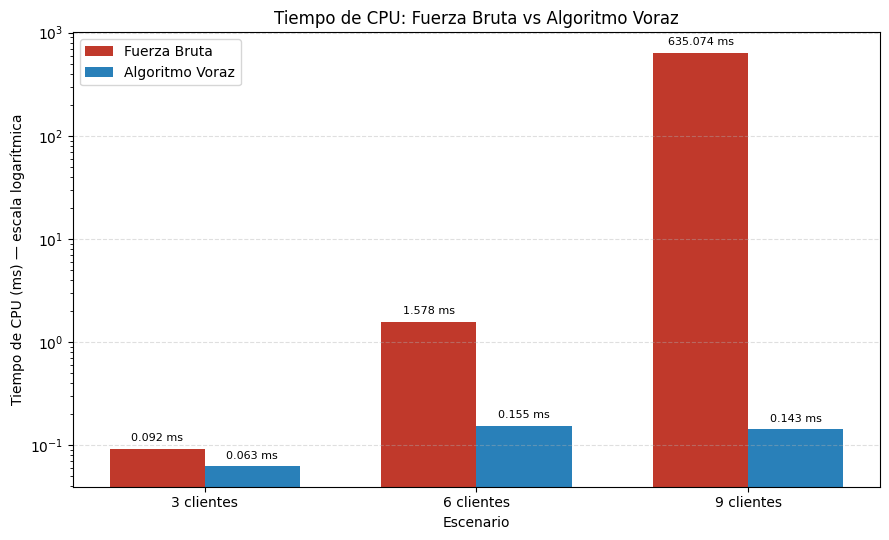


 3 clientes -> FB: 0.0924 ms (Sí) | Voraz: 0.0629 ms | Voraz es ~1x más rápido en CPU
 6 clientes -> FB: 1.5783 ms (No encontró solución factible) | Voraz: 0.1545 ms | Voraz es ~10x más rápido en CPU
 9 clientes -> FB: 635.0738 ms (No encontró solución factible) | Voraz: 0.1428 ms | Voraz es ~4447x más rápido en CPU


In [ ]:
# =============================================================================
# GRAFICO 1: CPU Fuerza Bruta vs Voraz en los 3 escenarios
# =============================================================================

escenarios = ["3", "6", "9"]
etiquetas = [f"{n} clientes" for n in escenarios]
cpu_fb_vals = [resultados[n]["cpu_fb"] for n in escenarios]
cpu_vz_vals = [resultados[n]["cpu_vz"] for n in escenarios]

x = np.arange(len(escenarios))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
barras_fb = ax.bar(x - ancho/2, cpu_fb_vals, ancho, label="Fuerza Bruta", color="#c0392b")
barras_vz = ax.bar(x + ancho/2, cpu_vz_vals, ancho, label="Algoritmo Voraz", color="#2980b9")

ax.set_yscale("log")
ax.set_ylabel("Tiempo de CPU (ms) — escala logarítmica")
ax.set_xlabel("Escenario")
ax.set_title("Tiempo de CPU: Fuerza Bruta vs Algoritmo Voraz")
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

for barras in (barras_fb, barras_vz):
    for b in barras:
        h = b.get_height()
        ax.annotate(f"{h:.3f} ms", xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print()
for n in escenarios:
    r = resultados[n]
    factible = "Sí" if r["r_fb"] else "No encontró solución factible"
    speedup = r["cpu_fb"] / r["cpu_vz"] if r["cpu_vz"] > 0 else float("nan")
    print(f" {n} clientes -> FB: {r['cpu_fb']:.4f} ms ({factible}) | Voraz: {r['cpu_vz']:.4f} ms | Voraz es ~{speedup:.0f}x más rápido en CPU")


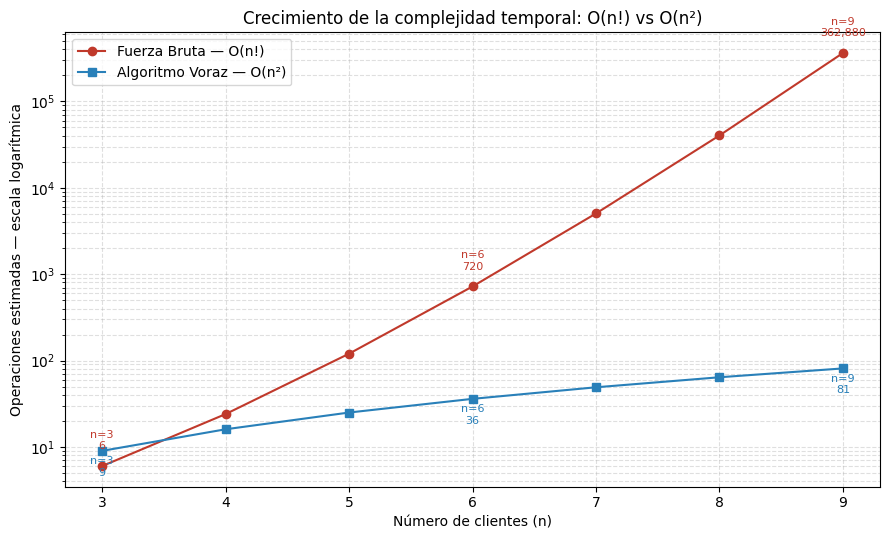

,n (clientes),O(n!) — Fuerza Bruta,O(n^2) — Voraz
0,3,6,9
1,4,24,16
2,5,120,25
3,6,720,36
4,7,5040,49
5,8,40320,64
6,9,362880,81


In [ ]:
# =============================================================================
# GRAFICO 2: Curva de crecimiento O(n!) vs O(n^2), n=3 a n=9
# =============================================================================

n_vals = np.arange(3, 10)  # 3,4,5,6,7,8,9
factorial_vals = [math.factorial(n) for n in n_vals]
cuadratico_vals = [n**2 for n in n_vals]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(n_vals, factorial_vals, marker="o", color="#c0392b", label="Fuerza Bruta — O(n!)")
ax.plot(n_vals, cuadratico_vals, marker="s", color="#2980b9", label="Algoritmo Voraz — O(n²)")

ax.set_yscale("log")
ax.set_xlabel("Número de clientes (n)")
ax.set_ylabel("Operaciones estimadas — escala logarítmica")
ax.set_title("Crecimiento de la complejidad temporal: O(n!) vs O(n²)")
ax.set_xticks(n_vals)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend()

# Resaltar los 3 escenarios evaluados (n=3, 6, 9)
for n_marca in (3, 6, 9):
    idx = list(n_vals).index(n_marca)
    ax.annotate(f"n={n_marca}\n{factorial_vals[idx]:,}",
                xy=(n_marca, factorial_vals[idx]), xytext=(0, 12),
                textcoords="offset points", ha="center", fontsize=8, color="#c0392b")
    ax.annotate(f"n={n_marca}\n{cuadratico_vals[idx]:,}",
                xy=(n_marca, cuadratico_vals[idx]), xytext=(0, -18),
                textcoords="offset points", ha="center", fontsize=8, color="#2980b9")

plt.tight_layout()
plt.show()

tabla_crecimiento = pd.DataFrame({
    "n (clientes)": n_vals,
    "O(n!) — Fuerza Bruta": factorial_vals,
    "O(n^2) — Voraz": cuadratico_vals,
})
tabla_crecimiento


In [ ]:
# =============================================================================
# MAPAS 
# =============================================================================

import folium
from folium.plugins import Fullscreen
from IPython.display import display
import math

# Paleta de colores
COLORES_MOTO_VIVOS = [
    "#e41a1c",  # rojo
    "#377eb8",  # azul
    "#4daf4a",  # verde
    "#984ea3",  # morado
    "#ff7f00",  # naranja
    "#ffff33",  # amarillo
    "#a65628",  # marrón
    "#f781bf",  # rosa
    "#999999",  # gris
]

def agregar_flechas_segmento(mapa, p1, p2, color, label=""):
    """
    Agrega una flecha en el punto medio del segmento p1->p2.
    """
    lat_mid = (p1[0] + p2[0]) / 2
    lon_mid = (p1[1] + p2[1]) / 2
    # Calcular ángulo en grados (0 = norte, sentido horario)
    delta_lat = p2[0] - p1[0]
    delta_lon = p2[1] - p1[1]
    angulo_rad = math.atan2(delta_lon, delta_lat)  # atan2(dy, dx) en coordenadas geográficas
    angulo_grados = math.degrees(angulo_rad) - 90  # ajuste para que apunte en dirección del movimiento
    # Icono HTML con una flecha usando CSS rotate
    html = f'''
        <div style="font-size: 16px; color: {color}; transform: rotate({angulo_grados}deg); 
                    text-align: center; line-height: 1; font-weight: bold;">
            ▶
        </div>
    '''
    iframe = folium.DivIcon(html=html)
    folium.Marker(
        [lat_mid, lon_mid],
        icon=iframe,
        tooltip=label or "Dirección"
    ).add_to(mapa)


def construir_mapa_mejorado(rutas_por_moto, clientes_data, titulo, color_offset=0):
    """
    Crea un mapa Folium con rutas, flechas direccionales, leyenda y popups.
    """
    base = CATALOGO_UBICACIONES[1]
    mapa = folium.Map(location=[base["lat"], base["lon"]], zoom_start=13,
                      tiles="cartodbpositron", control_scale=True)

    # Marcador de la base
    folium.Marker(
        [base["lat"], base["lon"]],
        popup="<b>Base</b><br>" + nombre_ubicacion(1),
        tooltip="Base (Cocina Central)",
        icon=folium.Icon(color="black", icon="home", prefix="fa"),
    ).add_to(mapa)

    # Dibujar rutas
    for i, ruta in enumerate(rutas_por_moto):
        color = COLORES_MOTO_VIVOS[(i + color_offset) % len(COLORES_MOTO_VIVOS)]
        fg = folium.FeatureGroup(name=f"Moto {i+1}")
        puntos = [[CATALOGO_UBICACIONES[nid]["lat"], CATALOGO_UBICACIONES[nid]["lon"]] for nid in ruta]

        # Línea de la ruta (con un poco de transparencia)
        folium.PolyLine(
            puntos,
            color=color,
            weight=5,
            opacity=0.7,
            tooltip=f"Moto {i+1}",
            popup=f"<b>Moto {i+1}</b><br>Clientes: {len(ruta)-2}"
        ).add_to(fg)

        # Agregar flechas en cada segmento (excepto el último si vuelve a base, lo dejamos)
        for j in range(len(puntos)-1):
            p1 = puntos[j]
            p2 = puntos[j+1]
            agregar_flechas_segmento(mapa, p1, p2, color, f"Moto {i+1} segmento {j+1}")

        # Dibujar clientes
        for order, nid in enumerate(ruta):
            if nid == 1:
                continue
            u = CATALOGO_UBICACIONES[nid]
            info = clientes_data.get(nid, {})
            ventana = info.get('ventana', (0,0))
            popup_text = f"""
                <b>{u['nombre']}</b><br>
                Orden: {order}<br>
                Peso: {info.get('peso', 'N/A')} kg<br>
                Volumen: {info.get('volumen', 'N/A')} L<br>
                Ventana: {formato_hora_12h(ventana[0])} - {formato_hora_12h(ventana[1])}<br>
                Perecibilidad: {info.get('perecibilidad_etiqueta', 'N/A')}
            """
            folium.CircleMarker(
                [u["lat"], u["lon"]],
                radius=8,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.9,
                popup=popup_text,
                tooltip=f"{order}: {u['nombre']}",
            ).add_to(fg)

        fg.add_to(mapa)

    # Control de capas
    folium.LayerControl().add_to(mapa)

    # Leyenda
    legend_html = """
    <div style="position: fixed; 
                bottom: 30px; left: 30px; width: 200px; height: auto; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px; border-radius: 8px;
                box-shadow: 3px 3px 5px rgba(0,0,0,0.3);">
        <b>🚲 Leyenda</b><br>
    """
    for i, ruta in enumerate(rutas_por_moto):
        color = COLORES_MOTO_VIVOS[(i + color_offset) % len(COLORES_MOTO_VIVOS)]
        legend_html += f'<i class="fa fa-circle" style="color:{color};"></i> Moto {i+1}<br>'
    legend_html += '<hr><span style="font-size:12px;">▶ indica dirección</span></div>'
    mapa.get_root().html.add_child(folium.Element(legend_html))

    # Pantalla completa
    Fullscreen().add_to(mapa)

    # Título
    title_html = f'<h4 style="text-align:center; font-family:sans-serif; margin-top:5px;">{titulo}</h4>'
    mapa.get_root().html.add_child(folium.Element(title_html))

    return mapa


# =============================================================================
# GENERACIÓN DE MAPAS (3, 6 y 9 clientes)
# =============================================================================

# --- 1. Fuerza Bruta n=3 ---
ruta_fb_3 = resultados["3"]["r_fb"]
if ruta_fb_3:
    rutas_fb_3 = [ruta_fb_3]
    mapa_fb_3 = construir_mapa_mejorado(
        rutas_fb_3,
        clientes_data_3,
        "Escenario 3 clientes — FUERZA BRUTA (solución exacta)"
    )
    display(mapa_fb_3)

# --- 2. Voraz n=3 ---
rutas_vz_3 = resultados["3"]["rutas_vz"]
mapa_vz_3 = construir_mapa_mejorado(
    rutas_vz_3,
    clientes_data_3,
    "Escenario 3 clientes — VORAZ (heurística)",
    color_offset=2
)
display(mapa_vz_3)

# --- 3. Voraz n=6 ---
rutas_vz_6 = resultados["6"]["rutas_vz"]
mapa_vz_6 = construir_mapa_mejorado(
    rutas_vz_6,
    clientes_data_6,
    f"Escenario 6 clientes — VORAZ — {resultados['6']['motos_vz']} motos"
)
display(mapa_vz_6)

# --- 4. Voraz n=9 ---
rutas_vz_9 = resultados["9"]["rutas_vz"]
mapa_vz_9 = construir_mapa_mejorado(
    rutas_vz_9,
    clientes_data_9,
    f"Escenario 9 clientes — VORAZ — {resultados['9']['motos_vz']} motos",
    color_offset=1
)
display(mapa_vz_9)

In [ ]:
# =============================================================================
# TABLA RESUMEN COMPARATIVA
# =============================================================================

filas = []
for n in ["3", "6", "9"]:
    r = resultados[n]
    filas.append({
        "Escenario": f"{n} clientes",
        "Algoritmo": "Fuerza Bruta",
        "CPU (ms)": round(r["cpu_fb"], 4),
        "Tiempo ruta (h)": round(r["t_fb"], 2) if r["r_fb"] else "---",
        "Distancia (km)": round(r["dist_fb"], 2) if r["r_fb"] else "---",
        "Peajes (S/.)": round(r["p_fb"], 2) if r["r_fb"] else "---",
        "Unidades motorizadas": 1 if r["r_fb"] else "---",
        "Atendidos": f"{r['total_clientes']}/{r['total_clientes']}" if r["r_fb"] else "---",
        "Solución factible": "Sí" if r["r_fb"] else "No",
    })
    filas.append({
        "Escenario": f"{n} clientes",
        "Algoritmo": "Voraz",
        "CPU (ms)": round(r["cpu_vz"], 4),
        "Tiempo ruta (h)": round(r["t_vz"], 2),
        "Distancia (km)": round(r["dist_vz"], 2),
        "Peajes (S/.)": round(r["p_vz"], 2),
        "Unidades motorizadas": r["motos_vz"],
        "Atendidos": f"{r['atendidos_vz']}/{r['total_clientes']}",
        "Solución factible": "Sí",
    })

tabla_resumen = pd.DataFrame(filas)
tabla_resumen


,Escenario,Algoritmo,CPU (ms),Tiempo ruta (h),Distancia (km),Peajes (S/.),Unidades motorizadas,Atendidos,Solución factible
0,3 clientes,Fuerza Bruta,0.0924,1.44,19.33,0.0,1,3/3,Sí
1,3 clientes,Voraz,0.0629,1.44,19.36,0.0,1,3/3,Sí
2,6 clientes,Fuerza Bruta,1.5783,---,---,---,---,---,No
3,6 clientes,Voraz,0.1545,2.6,66.66,15.0,3,6/6,Sí
4,9 clientes,Fuerza Bruta,635.0738,---,---,---,---,---,No
5,9 clientes,Voraz,0.1428,2.78,116.81,22.5,6,9/9,Sí
